# Telco Customer Churn Prediction

In [1]:
!pip install imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              precision_recall_curve, f1_score, recall_score,
                              precision_score, accuracy_score, confusion_matrix)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')


## 1. Load data

7,043 customers, 21 columns, one telco company. Target is `Churn` (26.5% churned).

In [2]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

df = df.drop(columns=['customerID'])
print(f"Rows: {len(df)}, Columns: {df.shape[1]}")
print(f"Churn rate: {(df['Churn']=='Yes').mean():.3f}")
df.head()

Rows: 7043, Columns: 20
Churn rate: 0.265


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data cleaning

`TotalCharges` is stored as text because 11 rows are blank strings — these are all `tenure == 0`
customers (brand new, never billed). `isnull()` won't catch a blank string, only `NaN`, so this
has to be checked explicitly. Converting with `errors='coerce'` turns the blanks into real `NaN`,
then `fillna(0)` sets them to the true value: $0 billed so far.


In [5]:
# check for hidden blanks that isnull() misses
blank_check = (df.astype(str).apply(lambda c: c.str.strip() == '')).sum()
print("Hidden blank strings per column:\n", blank_check[blank_check > 0])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Hidden blank strings per column:
 TotalCharges    11
dtype: int64


## 3. Fix redundant categories

Six add-on columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`,
`StreamingMovies`) each carry a `"No internet service"` value, and `MultipleLines` carries
`"No phone service"`. Verified these are 100% redundant — they mark the exact same rows as
`InternetService == 'No'` / `PhoneService == 'No'`. Collapsing them removes 7 duplicate one-hot
columns later with zero information loss.

In [6]:
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']

for c in addon_cols:
    df[c] = df[c].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

## 4. Exploratory data analysis

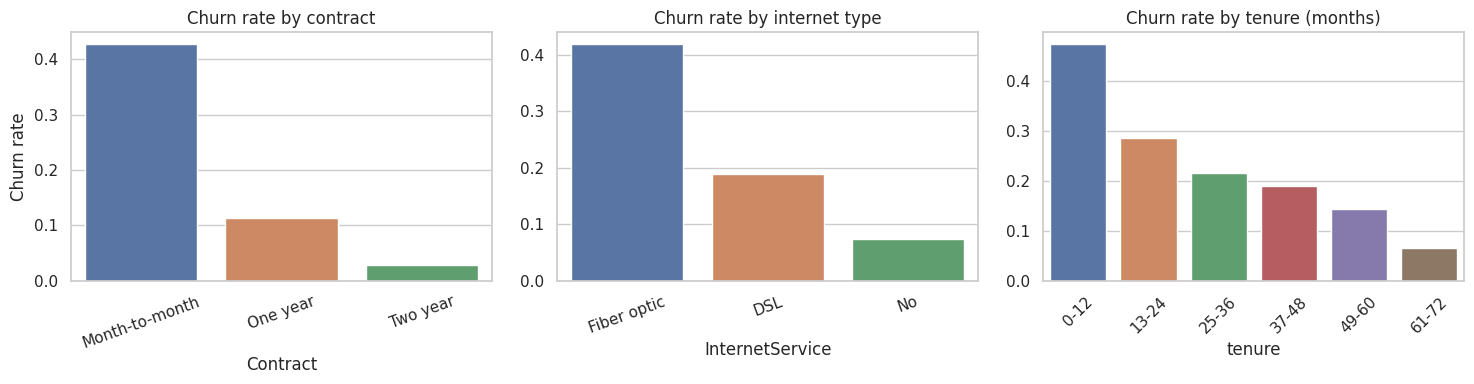

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=axes[0], hue='Contract', legend=False)
axes[0].set_title('Churn rate by contract')
axes[0].set_ylabel('Churn rate')
axes[0].tick_params(axis='x', rotation=20)

internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=internet_churn, x='InternetService', y='Churn', ax=axes[1], hue='InternetService', legend=False)
axes[1].set_title('Churn rate by internet type')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=20)

tenure_bins = pd.cut(df['tenure'], bins=[-1,12,24,36,48,60,72],
                      labels=['0-12','13-24','25-36','37-48','49-60','61-72'])
tenure_churn = df.groupby(tenure_bins, observed=True)['Churn'].mean().reset_index()
sns.barplot(data=tenure_churn, x='tenure', y='Churn', ax=axes[2], hue='tenure', legend=False)
axes[2].set_title('Churn rate by tenure (months)')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


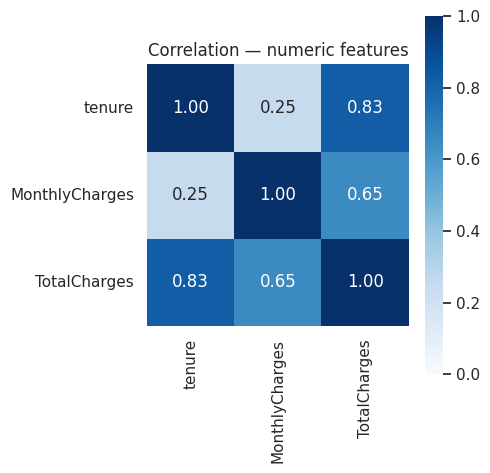

In [8]:
# correlation among the three continuous numeric features -- TotalCharges is
# near-derived from tenure x MonthlyCharges, worth knowing before modeling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar=True, ax=ax)
ax.set_title('Correlation — numeric features')
plt.tight_layout()
plt.show()


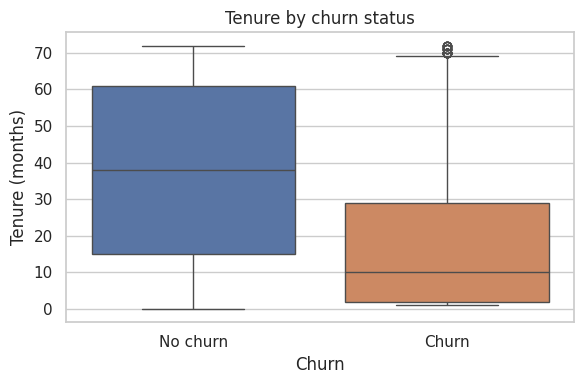

In [9]:
# tenure distribution split by churn -- new customers churn far more
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', legend=False, ax=ax)
ax.set_xticklabels(['No churn', 'Churn'])
ax.set_ylabel('Tenure (months)')
ax.set_title('Tenure by churn status')
plt.tight_layout()
plt.show()


## 5. Feature engineering

Tested several candidates against actual churn rates before adding anything:

- **`IsNewCustomer` (tenure ≤ 6 months), For Logistic Regression:.**  genuinely useful. It hands the model a real inflection point (48%→36% churn between month 5 and 6) it couldn't otherwise detect on its own.
  


In [10]:
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

## 6. Encode categorical features

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
print(f"Features: {X.shape[1]}  (30 in the original version -- redundant placeholder categories collapsed)")

Features: 24  (30 in the original version -- redundant placeholder categories collapsed)


## 7. Train/test split — before oversampling

Stratified, and this happens **before** any resampling — the test set must stay untouched and at
its real ~74/26 ratio, or the evaluation numbers become meaningless.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

Train: (5634, 24), Test: (1409, 24)
Train churn rate: 0.265 | Test churn rate: 0.265


## 8. Handle class imbalance, class weighting, not oversampling

Tested SMOTE, SMOTENC, and class weighting head-to-head on identical data. Class weighting won
on every model, on every metric that matters, without generating a single synthetic row:

| Technique | Best ROC-AUC | Best F1 |
|---|---|---|
| SMOTE | 0.836 | 0.610 |
| SMOTENC | 0.836 | 0.608 |
| Class weighting | **0.846** | **0.629** |



In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")

scale_pos_weight for XGBoost: 2.769


## 9. Scale numeric features

Fit on the training set as-is — no resampling happened, so no risk of fitting the scaler on a
resampled distribution. Only the continuous columns are scaled.

In [14]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## 10. Train models — class weighting + hyperparameter tuning (RandomizedSearchCV)

Each model is tuned with `RandomizedSearchCV` (5-fold stratified CV, scored on ROC-AUC) instead of
using fixed hyperparameters — the search picks the best combination from a defined range rather than
guessing one. No threshold tuning below: every model uses the standard 0.5 cutoff.

In [15]:
def evaluate_model(name, model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    print(f"--- {name} ---")
    print(classification_report(y_te, pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {roc_auc_score(y_te, proba):.4f}\n")
    return {
        'model': name,
        'accuracy': accuracy_score(y_te, pred),
        'f1_churn': f1_score(y_te, pred),
        'recall_churn': recall_score(y_te, pred),
        'precision_churn': precision_score(y_te, pred),
        'roc_auc': roc_auc_score(y_te, proba),
        'proba': proba,
        'pred': pred
    }

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [16]:
lr_param_dist = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1, 3, 5, 10],
    'penalty': ['l1', 'l2'],
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=42),
    lr_param_dist, n_iter=20, scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1
)
lr_search.fit(X_train_scaled, y_train)
lr = lr_search.best_estimator_
print(f"Logistic Regression — best params: {lr_search.best_params_}  (CV ROC-AUC: {lr_search.best_score_:.4f})")
results.append(evaluate_model('Logistic Regression', lr, X_test_scaled, y_test))


Logistic Regression — best params: {'penalty': 'l1', 'C': 10}  (CV ROC-AUC: 0.8480)
--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8447



In [17]:
rf_param_dist = {
    'n_estimators': [100, 150, 200, 300, 400, 500],
    'max_depth': [4, 5, 6, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_param_dist, n_iter=40, scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_
print(f"Random Forest — best params: {rf_search.best_params_}  (CV ROC-AUC: {rf_search.best_score_:.4f})")
results.append(evaluate_model('Random Forest', rf, X_test, y_test))


Random Forest — best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 6}  (CV ROC-AUC: 0.8478)
--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC: 0.8476



In [18]:
xgb_param_dist = {
    'n_estimators': [100, 150, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.02, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2, 5]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
    xgb_param_dist, n_iter=30, scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
xgb = xgb_search.best_estimator_
print(f"XGBoost — best params: {xgb_search.best_params_}  (CV ROC-AUC: {xgb_search.best_score_:.4f})")
results.append(evaluate_model('XGBoost', xgb, X_test, y_test))


XGBoost — best params: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}  (CV ROC-AUC: 0.8496)
--- XGBoost ---
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC: 0.8472



## 11. Compare models

In [19]:
results_df = pd.DataFrame(results)[['model', 'accuracy', 'precision_churn', 'recall_churn', 'f1_churn', 'roc_auc']]
results_df = results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(results_df.round(3))


                 model  accuracy  precision_churn  recall_churn  f1_churn  \
0        Random Forest     0.757            0.528         0.805     0.638   
1              XGBoost     0.750            0.519         0.805     0.631   
2  Logistic Regression     0.741            0.508         0.794     0.619   

   roc_auc  
0    0.848  
1    0.847  
2    0.845  


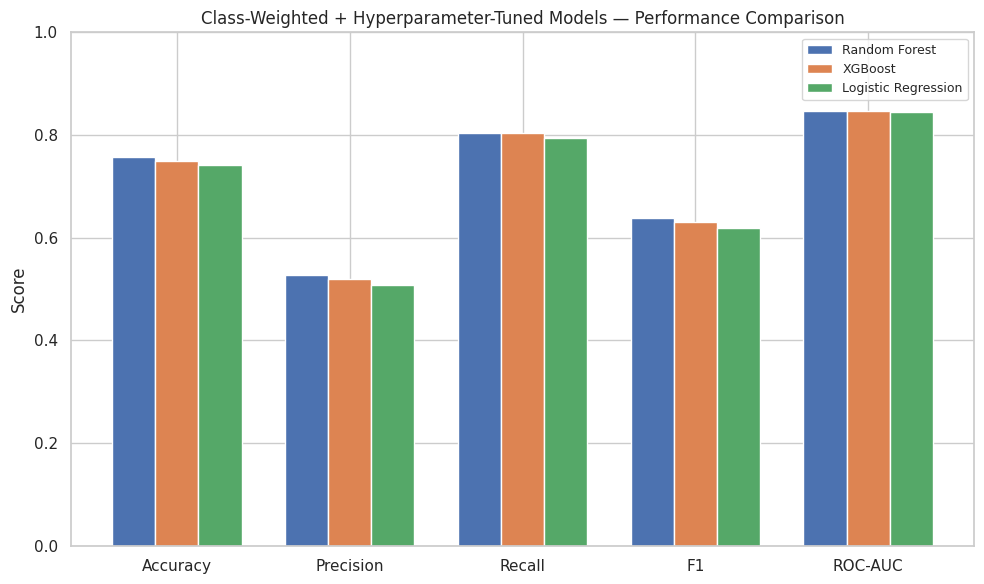

In [20]:
metrics = ['accuracy', 'precision_churn', 'recall_churn', 'f1_churn', 'roc_auc']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, row in results_df.iterrows():
    ax.bar(x + i * width, row[metrics].values, width, label=row['model'])

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
ax.set_ylabel('Score')
ax.set_title('Class-Weighted + Hyperparameter-Tuned Models — Performance Comparison')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

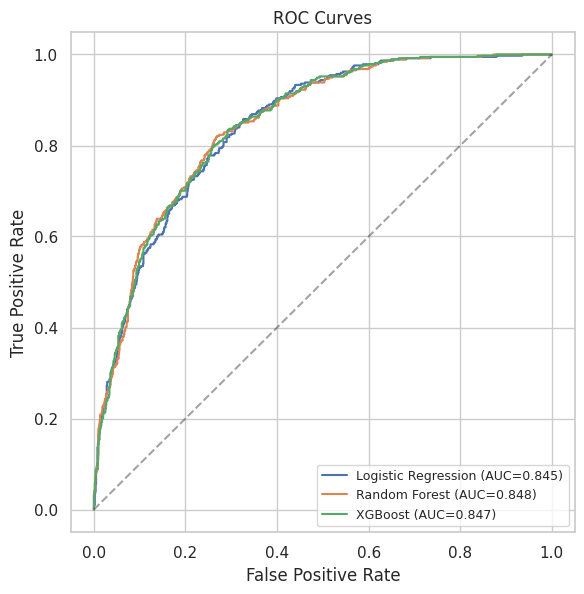

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    ax.plot(fpr, tpr, label=f"{r['model']} (AUC={r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=9)
plt.show()

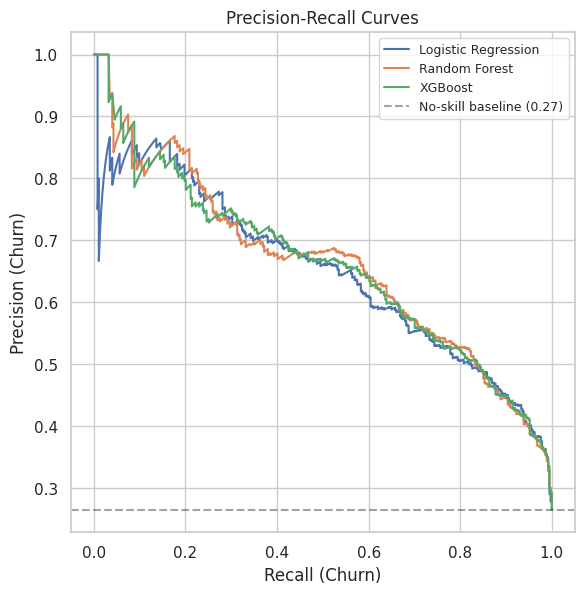

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for r in results:
    prec, rec, _ = precision_recall_curve(y_test, r['proba'])
    ax.plot(rec, prec, label=r['model'])
baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f'No-skill baseline ({baseline:.2f})')
ax.set_xlabel('Recall (Churn)')
ax.set_ylabel('Precision (Churn)')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=9)
plt.show()

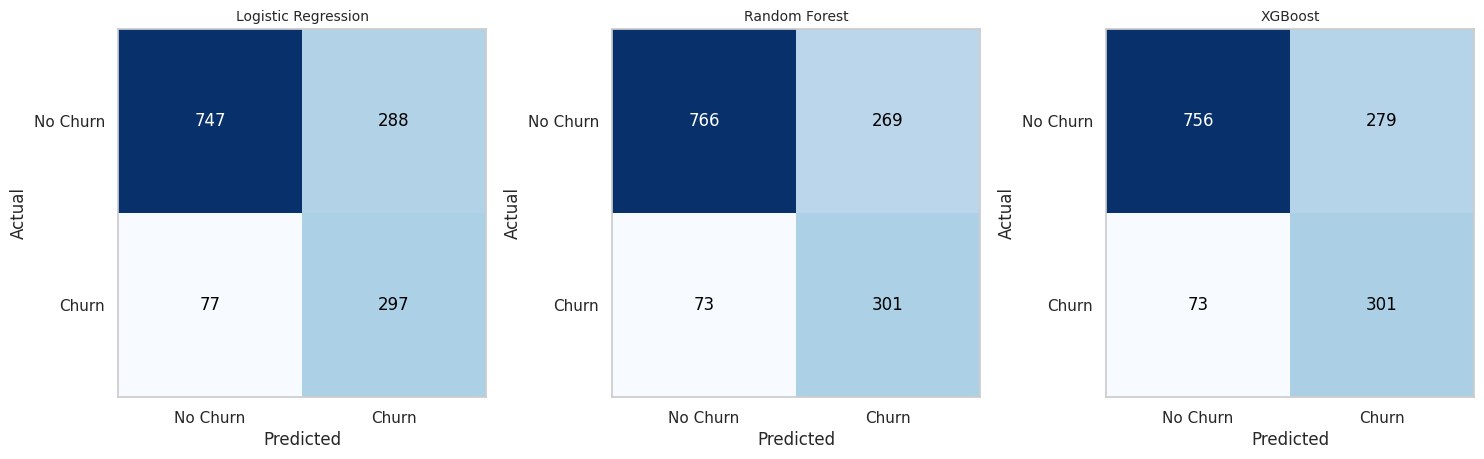

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['pred'])
    ax.imshow(cm, cmap='Blues')
    ax.grid(False)
    ax.set_title(r['model'], fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['No Churn', 'Churn'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Save the best model

Picked by F1, since that's the metric that actually reflects churn-catching performance for this
use case — not ROC-AUC alone and not accuracy. Saves the tuned model, the scaler, and the column
order — all needed to correctly score a new customer later.

In [24]:
model_map = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}

best_row = results_df.sort_values('f1_churn', ascending=False).iloc[0]
best_model_name = best_row['model']
print(f"Best model by F1: {best_model_name} (F1={best_row['f1_churn']:.3f}, ROC-AUC={best_row['roc_auc']:.3f})")

best_model = model_map[best_model_name]

joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')
joblib.dump(best_model_name, 'best_model_name.pkl')

print("Saved: churn_model.pkl, scaler.pkl, model_columns.pkl, best_model_name.pkl")


Best model by F1: Random Forest (F1=0.638, ROC-AUC=0.848)
Saved: churn_model.pkl, scaler.pkl, model_columns.pkl, best_model_name.pkl


## 13. Predictive system, score a brand-new customer

Loads the saved model, scaler, and column order back from disk and scores a single new customer
passed in as a raw dictionary (same format as a row of the original CSV, minus `customerID` and
`Churn`).



In [25]:
loaded_model = joblib.load('churn_model.pkl')
loaded_columns = joblib.load('model_columns.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_model_name = joblib.load('best_model_name.pkl')

def predict_new_customer(raw_customer: dict):
    """raw_customer: dict with the same keys as the original CSV columns
    (excluding customerID and Churn). Returns (prediction, churn_probability)."""
    row = pd.DataFrame([raw_customer])

    row['TotalCharges'] = pd.to_numeric(row['TotalCharges'], errors='coerce').fillna(0)
    for c in ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']:
        row[c] = row[c].replace('No internet service', 'No')
    row['MultipleLines'] = row['MultipleLines'].replace('No phone service', 'No')
    row['IsNewCustomer'] = (row['tenure'] <= 6).astype(int)

    cat_cols_row = row.select_dtypes(include='object').columns.tolist()
    row_encoded = pd.get_dummies(row, columns=cat_cols_row, drop_first=True)
    row_encoded = row_encoded.reindex(columns=loaded_columns, fill_value=0)

    if loaded_model_name == 'Logistic Regression':
        row_encoded[num_cols] = loaded_scaler.transform(row_encoded[num_cols])

    proba = loaded_model.predict_proba(row_encoded)[0][1]
    pred = int(proba >= 0.5)
    return pred, proba


new_customer = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.0, 'TotalCharges': 190.0
}

pred, proba = predict_new_customer(new_customer)
print(f"Model used: {loaded_model_name}")
print(f"Prediction: {'Churn' if pred == 1 else 'No Churn'}")
print(f"Churn probability: {proba:.3f}")


Model used: Random Forest
Prediction: Churn
Churn probability: 0.663
